In [1]:
%pip install -U -q google-cloud-aiplatform[evaluation]
%pip install -U -q datasets anthropic[vertex] openai

In [2]:
# Automatically restart kernel after installation so that your environment can access the new packages.
import IPython

app = IPython.Application.instance()
app.kernel.do_shutdown(True)


{'status': 'ok', 'restart': True}

In [ ]:
# Configure your project settings
PROJECT_ID = "my-project-itai1372"
LOCATION = "us-central1"

In [ ]:
from anthropic import AnthropicVertex
from google.auth import default, transport
import openai
import pandas as pd
from vertexai.evaluation import (
   EvalTask,
   MetricPromptTemplateExamples,
   PairwiseMetric,
   PointwiseMetric,
   PointwiseMetricPromptTemplate,
)
from vertexai.generative_models import GenerativeModel
from vertexai.preview.evaluation import notebook_utils

/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.aiplatform_v1beta1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.aiplatform_v1beta1 past that date.
  warnings.warn(message, FutureWarning)
/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.aiplatform_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.aiplatform_v1 past that date.
  warnings.warn(message, FutureWarning)
/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_supp

In [ ]:
from datasets import load_dataset

ds = (
   load_dataset(
      "Open-Orca/OpenOrca",
      data_files="1M-GPT4-Augmented.parquet",
      split="train[:100]",
   )
   .to_pandas()
   .drop(columns=["id"])
   .rename(columns={"response": "reference"})
)

dataset = ds.sample(n=10)

README.md: 0.00B [00:00, ?B/s]

1M-GPT4-Augmented.parquet:   0%|          | 0.00/1.01G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
dataset.head()

,system_prompt,question,reference
28,,Detailed Instructions: In this task you will b...,To solve this expression with the swapped oper...
9,You are an AI assistant. User will you give yo...,Premise: A man is inline skating in front of a...,b). it is not possible to tell\n\nJustificatio...
22,You are an AI assistant. User will you give yo...,Can you generate a question with a factual ans...,Step 1: Choose a topic. I'll select geography ...
53,You are an AI assistant. User will you give yo...,I am verifying the answers generated by an aut...,"To verify the answer, I will:\n1. Understand t..."
88,You are an AI assistant that follows instructi...,\n\nJordan called their grandparents after the...,Jordan can be described as someone who is reso...


In [ ]:
# Model to be evaluated
model = GenerativeModel(
    "gemini-2.0-flash",
    generation_config={"temperature": 0.6, "max_output_tokens": 256, "top_k": 1},
)

In [ ]:
# Define an EvalTask with ROUGE-L-SUM metric
rouge_eval_task = EvalTask(
    dataset=dataset,
    metrics=["rouge_l_sum"],
)
rouge_result = rouge_eval_task.evaluate(
    model=model,
    prompt_template="# System_prompt\n{system_prompt} # Question\n{question}",
)

Assembling prompts from the `prompt_template`. The `prompt` column in the `EvalResult.metrics_table` has the assembled prompts used for model response generation.
Generating a total of 10 responses from Gemini model gemini-2.0-flash.


100%|██████████| 10/10 [00:02<00:00,  3.91it/s]

All 10 responses are successfully generated from Gemini model gemini-2.0-flash.
Multithreaded Batch Inference took: 2.5784389020000162 seconds.
Computing metrics with a total of 10 Vertex Gen AI Evaluation Service API requests.



100%|██████████| 10/10 [00:00<00:00, 10.09it/s]

All 10 metric requests are successfully computed.
Evaluation Took:1.0038073079999776 seconds


In [ ]:
notebook_utils.display_eval_result(rouge_result)

### Summary Metrics

,row_count,rouge_l_sum/mean,rouge_l_sum/std
0,10.0,0.292877,0.103861


### Row-based Metrics

,system_prompt,question,reference,prompt,response,rouge_l_sum/score
0,,Detailed Instructions: In this task you will b...,To solve this expression with the swapped oper...,# System_prompt\n # Question\nDetailed Instruc...,7716 - 6322 - 6665 + 1281 - 1377 - 3345 - 8318...,0.210526
1,You are an AI assistant. User will you give yo...,Premise: A man is inline skating in front of a...,b). it is not possible to tell\n\nJustificatio...,# System_prompt\nYou are an AI assistant. User...,"Okay, let's analyze this.\n\n* **Premise:** ...",0.333333
2,You are an AI assistant. User will you give yo...,Can you generate a question with a factual ans...,Step 1: Choose a topic. I'll select geography ...,# System_prompt\nYou are an AI assistant. User...,"Okay, I understand. I need to generate a quest...",0.309735
3,You are an AI assistant. User will you give yo...,I am verifying the answers generated by an aut...,"To verify the answer, I will:\n1. Understand t...",# System_prompt\nYou are an AI assistant. User...,Let's analyze the suggested answer in relation...,0.236735
4,You are an AI assistant that follows instructi...,\n\nJordan called their grandparents after the...,Jordan can be described as someone who is reso...,# System_prompt\nYou are an AI assistant that ...,"Given the context, I would describe Jordan as:...",0.275229
5,You are an AI assistant that helps people find...,Please answer the following question by reason...,- no.\n\nStep-by-step reasoning:\n1. The state...,# System_prompt\nYou are an AI assistant that ...,Welding is a process that joins metals by caus...,0.329545
6,"You are a helpful assistant, who always provid...",Even after Bin Laden's departure from the are...,"The provided response ""UAE"" does not correctly...","# System_prompt\nYou are a helpful assistant, ...","Okay, let's break this down like we're explain...",0.136364
7,You are an AI assistant. You will be given a t...,Generate a movie review with positive sentiment.,Title: The Visionary Voyage\n\nMovie Review:\n...,# System_prompt\nYou are an AI assistant. You ...,"Okay, here's a detailed movie review with a st...",0.196248
8,You are an AI assistant that follows instructi...,Please answer the following question: I am try...,Spider-Man suspects that Dr. Connor is the Liz...,# System_prompt\nYou are an AI assistant that ...,Spider-Man suspects Connor is experimenting wi...,0.454545
9,You are an AI assistant. User will you give yo...,Question: I read this background article the o...,Lake Mahoe likely has more chemicals in it tha...,# System_prompt\nYou are an AI assistant. User...,"Okay, I understand the task. I need to compare...",0.446512


In [ ]:
#Select a pointwise metric to use

import ipywidgets as widgets

pointwise_single_turn_metrics = [
    metric
    for metric in MetricPromptTemplateExamples.list_example_metric_names()
    if not metric.startswith("pairwise") and not metric.startswith("multi_turn")
]

dropdown = widgets.Dropdown(
    options=pointwise_single_turn_metrics,
    description="Select a metric:",
    font_weight="bold",
    style={"description_width": "initial"},
)

def dropdown_eventhandler(change):
    global POINTWISE_METRIC
    if change["type"] == "change" and change["name"] == "value":
        POINTWISE_METRIC = change.new
        print("Selected:", change.new)

POINTWISE_METRIC = dropdown.value
dropdown.observe(dropdown_eventhandler, names="value")
display(dropdown)

Dropdown(description='Select a metric:', options=('coherence', 'fluency', 'safety', 'groundedness', 'instructi…

In [ ]:
pointwise_result = EvalTask(
    dataset=dataset,
    metrics=[POINTWISE_METRIC],
).evaluate(
    model=model,
    prompt_template="# System_prompt\n{system_prompt} # Question\n{question}",
)

Assembling prompts from the `prompt_template`. The `prompt` column in the `EvalResult.metrics_table` has the assembled prompts used for model response generation.
Generating a total of 10 responses from Gemini model gemini-2.0-flash.


100%|██████████| 10/10 [00:02<00:00,  3.96it/s]

All 10 responses are successfully generated from Gemini model gemini-2.0-flash.
Multithreaded Batch Inference took: 2.5375892429999567 seconds.
Computing metrics with a total of 10 Vertex Gen AI Evaluation Service API requests.



100%|██████████| 10/10 [00:23<00:00,  2.38s/it]

All 10 metric requests are successfully computed.
Evaluation Took:23.85481557099979 seconds


In [ ]:
notebook_utils.display_eval_result(pointwise_result)

### Summary Metrics

,row_count,coherence/mean,coherence/std
0,10.0,4.6,0.699206


### Row-based Metrics

,system_prompt,question,reference,prompt,response,coherence/explanation,coherence/score
0,,Detailed Instructions: In this task you will b...,To solve this expression with the swapped oper...,# System_prompt\n # Question\nDetailed Instruc...,7716 - 6322 - 6665 + 1281 - 1377 - 3345 - 8318...,The response correctly interprets the swapped ...,5.0
1,You are an AI assistant. User will you give yo...,Premise: A man is inline skating in front of a...,b). it is not possible to tell\n\nJustificatio...,# System_prompt\nYou are an AI assistant. User...,"Okay, let's analyze this.\n\n* **Premise:** ...",The response demonstrates a seamless logical f...,5.0
2,You are an AI assistant. User will you give yo...,Can you generate a question with a factual ans...,Step 1: Choose a topic. I'll select geography ...,# System_prompt\nYou are an AI assistant. User...,"Okay, I understand. I need to generate a quest...","The writing has a seamless logical flow, start...",5.0
3,You are an AI assistant. User will you give yo...,I am verifying the answers generated by an aut...,"To verify the answer, I will:\n1. Understand t...",# System_prompt\nYou are an AI assistant. User...,Let's analyze the suggested answer and the que...,The response provides a clear and logical step...,3.0
4,You are an AI assistant that follows instructi...,\n\nJordan called their grandparents after the...,Jordan can be described as someone who is reso...,# System_prompt\nYou are an AI assistant that ...,"Given the context, I would describe Jordan as:...",The response demonstrates a seamless logical f...,5.0
5,You are an AI assistant that helps people find...,Please answer the following question by reason...,- no.\n\nStep-by-step reasoning:\n1. The state...,# System_prompt\nYou are an AI assistant that ...,Welding is a process that joins metals by caus...,The response demonstrates a seamless logical f...,5.0
6,"You are a helpful assistant, who always provid...",Even after Bin Laden's departure from the are...,"The provided response ""UAE"" does not correctly...","# System_prompt\nYou are a helpful assistant, ...",Let's break down the story to understand the a...,The response demonstrates a seamless logical f...,5.0
7,You are an AI assistant. You will be given a t...,Generate a movie review with positive sentiment.,Title: The Visionary Voyage\n\nMovie Review:\n...,# System_prompt\nYou are an AI assistant. You ...,"Okay, here's a detailed and glowing movie revi...","The writing has a seamless logical flow, is ex...",5.0
8,You are an AI assistant that follows instructi...,Please answer the following question: I am try...,Spider-Man suspects that Dr. Connor is the Liz...,# System_prompt\nYou are an AI assistant that ...,Spider-Man suspects Connor is researching cros...,The response demonstrates strong logical flow ...,4.0
9,You are an AI assistant. User will you give yo...,Question: I read this background article the o...,Lake Mahoe likely has more chemicals in it tha...,# System_prompt\nYou are an AI assistant. User...,"Okay, I understand the task. I need to use the...","The response provides a very clear, step-by-st...",4.0


In [ ]:
notebook_utils.display_explanations(pointwise_result, num=1, metrics=[POINTWISE_METRIC])

In [ ]:
# This new custom metric evaluates the actual quality and usefulness of the summary.

summarization_helpfulness_metric = PointwiseMetric(
    metric="summarization_helpfulness",
    metric_prompt_template=PointwiseMetricPromptTemplate(
        criteria={
            "Key Information": "Does the summary capture the most critical pieces of information from the original text? It should not miss the main topic or key takeaways.",
            "Conciseness": "Is the summary brief and to the point? It should avoid unnecessary words or repetitive information.",
            "No Distortion": "Does the summary introduce information or opinions that were NOT present in the original text? It must accurately reflect the source material without adding hallucinations."
        },
        rating_rubric={
            "5": "Excellent: Captures all key information, is highly concise, and has zero distortion.",
            "4": "Good: Captures most key information with minor omissions, is concise, and has no distortion.",
            "3": "Satisfactory: Captures the main idea but misses some key details OR is not very concise.",
            "2": "Unsatisfactory: Misses the main idea of the original text OR contains minor distortions/hallucinations.",
            "1": "Poor: Is completely irrelevant, fails to summarize the text, OR contains significant distortions.",
        },
        input_variables=["prompt", "reference"],
    ),
)

In [ ]:
# You would then update the EvalTask to use this new metric
pointwise_result = EvalTask(
    dataset=dataset,
    metrics=[summarization_helpfulness_metric],
).evaluate(
    model=model,
    prompt_template="# System_prompt\n{system_prompt} # Question\n{question}",
)

Assembling prompts from the `prompt_template`. The `prompt` column in the `EvalResult.metrics_table` has the assembled prompts used for model response generation.
Generating a total of 10 responses from Gemini model gemini-2.0-flash.


100%|██████████| 10/10 [00:02<00:00,  4.33it/s]

All 10 responses are successfully generated from Gemini model gemini-2.0-flash.
Multithreaded Batch Inference took: 2.3199104370000896 seconds.
Computing metrics with a total of 10 Vertex Gen AI Evaluation Service API requests.



100%|██████████| 10/10 [00:21<00:00,  2.13s/it]

All 10 metric requests are successfully computed.
Evaluation Took:21.282119016999786 seconds


In [ ]:
notebook_utils.display_eval_result(pointwise_result)

### Summary Metrics

,row_count,summarization_helpfulness/mean,summarization_helpfulness/std
0,10.0,3.8,1.398412


### Row-based Metrics

,system_prompt,question,reference,prompt,response,summarization_helpfulness/explanation,summarization_helpfulness/score
0,,Detailed Instructions: In this task you will b...,To solve this expression with the swapped oper...,# System_prompt\n # Question\nDetailed Instruc...,7716 - 6322 - 6665 + 1281 - 1377 - 3345 - 8318...,"The response is highly concise, accurately app...",5.0
1,You are an AI assistant. User will you give yo...,Premise: A man is inline skating in front of a...,b). it is not possible to tell\n\nJustificatio...,# System_prompt\nYou are an AI assistant. User...,"Okay, let's analyze this.\n\n* **Premise:** ...",The AI response correctly identifies the answe...,5.0
2,You are an AI assistant. User will you give yo...,Can you generate a question with a factual ans...,Step 1: Choose a topic. I'll select geography ...,# System_prompt\nYou are an AI assistant. User...,"Okay, I understand. I need to generate a quest...",The AI successfully generated a question with ...,5.0
3,You are an AI assistant. User will you give yo...,I am verifying the answers generated by an aut...,"To verify the answer, I will:\n1. Understand t...",# System_prompt\nYou are an AI assistant. User...,Let's analyze the suggested answer in relation...,The response provides an excellent analysis of...,3.0
4,You are an AI assistant that follows instructi...,\n\nJordan called their grandparents after the...,Jordan can be described as someone who is reso...,# System_prompt\nYou are an AI assistant that ...,"Given the context, I would describe Jordan as:...",The response captures the main idea of Jordan ...,3.0
5,You are an AI assistant that helps people find...,Please answer the following question by reason...,- no.\n\nStep-by-step reasoning:\n1. The state...,# System_prompt\nYou are an AI assistant that ...,Welding is a process that joins metals by caus...,The response correctly identifies the distinct...,5.0
6,"You are a helpful assistant, who always provid...",Even after Bin Laden's departure from the are...,"The provided response ""UAE"" does not correctly...","# System_prompt\nYou are a helpful assistant, ...",Let's break down the question and the answer l...,The AI's response correctly analyzes the initi...,5.0
7,You are an AI assistant. You will be given a t...,Generate a movie review with positive sentiment.,Title: The Visionary Voyage\n\nMovie Review:\n...,# System_prompt\nYou are an AI assistant. You ...,"Okay, here's a detailed and enthusiastic movie...",The AI successfully understood the prompt to g...,3.0
8,You are an AI assistant that follows instructi...,Please answer the following question: I am try...,Spider-Man suspects that Dr. Connor is the Liz...,# System_prompt\nYou are an AI assistant that ...,Spider-Man suspects that Connor is working on ...,The AI response completely ignores the provide...,1.0
9,You are an AI assistant. User will you give yo...,Question: I read this background article the o...,Lake Mahoe likely has more chemicals in it tha...,# System_prompt\nYou are an AI assistant. User...,"Okay, I understand the task. I need to compare...",The AI response correctly identifies the main ...,3.0


In [ ]:
from IPython.display import display
import ipywidgets as widgets

pairwise_single_turn_metrics = [
    metric
    for metric in MetricPromptTemplateExamples.list_example_metric_names()
    if metric.startswith("pairwise") and "multi_turn" not in metric
]

dropdown = widgets.Dropdown(
    options=pairwise_single_turn_metrics,
    description="Select a metric:",
    font_weight="bold",
    style={"description_width": "initial"},
)

def dropdown_eventhandler(change):
    global POINTWISE_METRIC
    if change["type"] == "change" and change["name"] == "value":
        POINTWISE_METRIC = change.new
        print("Selected:", change.new)

def dropdown_eventhandler(change):
    global PAIRWISE_METRIC_NAME
    if change["type"] == "change" and change["name"] == "value":
        PAIRWISE_METRIC_NAME = change.new
        print("Selected:", change.new)


PAIRWISE_METRIC_NAME = dropdown.value
dropdown.observe(dropdown_eventhandler, names="value")
display(dropdown)

Dropdown(description='Select a metric:', options=('pairwise_coherence', 'pairwise_fluency', 'pairwise_safety',…

In [ ]:
pairwise_result = EvalTask(
    dataset=dataset,
    metrics=[
        PairwiseMetric(
            metric=PAIRWISE_METRIC_NAME,
            metric_prompt_template=MetricPromptTemplateExamples.get_prompt_template(
                PAIRWISE_METRIC_NAME
            ),
            # Define a baseline model to compare against
            baseline_model=GenerativeModel("gemini-2.0-flash-lite"),
        )
    ],
).evaluate(
    # Specify a candidate model for pairwise comparison
    model=model,
    prompt_template="# System_prompt\n{system_prompt} # Question\n{question}",
)

Assembling prompts from the `prompt_template`. The `prompt` column in the `EvalResult.metrics_table` has the assembled prompts used for model response generation.
Generating a total of 10 responses from Gemini model gemini-2.0-flash.


100%|██████████| 10/10 [00:02<00:00,  4.30it/s]

All 10 responses are successfully generated from Gemini model gemini-2.0-flash.
Multithreaded Batch Inference took: 2.336436412999774 seconds.
Generating a total of 10 responses from Gemini model gemini-2.0-flash-lite.



100%|██████████| 10/10 [00:07<00:00,  1.25it/s]

All 10 responses are successfully generated from Gemini model gemini-2.0-flash-lite.
Multithreaded Batch Inference took: 7.988056804999815 seconds.
Computing metrics with a total of 10 Vertex Gen AI Evaluation Service API requests.



100%|██████████| 10/10 [00:16<00:00,  1.63s/it]

All 10 metric requests are successfully computed.
Evaluation Took:16.33722273500007 seconds


In [ ]:
notebook_utils.display_eval_result(pairwise_result)

### Summary Metrics

,row_count,pairwise_coherence/candidate_model_win_rate,pairwise_coherence/baseline_model_win_rate
0,10.0,0.3,0.7


### Row-based Metrics

,system_prompt,question,reference,prompt,response,baseline_model_response,pairwise_coherence/explanation,pairwise_coherence/pairwise_choice
0,,Detailed Instructions: In this task you will b...,To solve this expression with the swapped oper...,# System_prompt\n # Question\nDetailed Instruc...,7716 - 6322 - 6665 + 1281 - 1377 - 3345 - 8318...,7716 - 6322 - 6665 + 1281 - 1377 - 3345 - 8318...,Both responses correctly interpret the swapped...,CANDIDATE
1,You are an AI assistant. User will you give yo...,Premise: A man is inline skating in front of a...,b). it is not possible to tell\n\nJustificatio...,# System_prompt\nYou are an AI assistant. User...,"Okay, let's analyze this.\n\n* **Premise:** ...",Here's how we can analyze the question:\n\n1. ...,Both responses correctly answer the question a...,BASELINE
2,You are an AI assistant. User will you give yo...,Can you generate a question with a factual ans...,Step 1: Choose a topic. I'll select geography ...,# System_prompt\nYou are an AI assistant. User...,"Okay, I understand. I need to generate a quest...","Okay, I will generate a question with a factua...",Both responses generate a factual question and...,BASELINE
3,You are an AI assistant. User will you give yo...,I am verifying the answers generated by an aut...,"To verify the answer, I will:\n1. Understand t...",# System_prompt\nYou are an AI assistant. User...,Let's analyze the suggested answer to determin...,Here's my thought process to determine whether...,BASELINE response provides a complete and cohe...,BASELINE
4,You are an AI assistant that follows instructi...,\n\nJordan called their grandparents after the...,Jordan can be described as someone who is reso...,# System_prompt\nYou are an AI assistant that ...,"Given the context, I would describe Jordan as:...","Based on the context, we can infer the followi...",CANDIDATE response provides more accurate and ...,CANDIDATE
5,You are an AI assistant that helps people find...,Please answer the following question by reason...,- no.\n\nStep-by-step reasoning:\n1. The state...,# System_prompt\nYou are an AI assistant that ...,Welding is a process that joins metals by caus...,Here's my reasoning:\n\n1. **Welding and Cutt...,"BASELINE response provides clear, numbered, st...",BASELINE
6,"You are a helpful assistant, who always provid...",Even after Bin Laden's departure from the are...,"The provided response ""UAE"" does not correctly...","# System_prompt\nYou are a helpful assistant, ...",Let's break this down like we're explaining it...,The question asks why the threat from Hamdan b...,CANDIDATE response correctly identifies that t...,CANDIDATE
7,You are an AI assistant. You will be given a t...,Generate a movie review with positive sentiment.,Title: The Visionary Voyage\n\nMovie Review:\n...,# System_prompt\nYou are an AI assistant. You ...,"Okay, here's a detailed and glowing movie revi...","Okay, here's a movie review with a positive se...","BASELINE response provides a complete, detaile...",BASELINE
8,You are an AI assistant that follows instructi...,Please answer the following question: I am try...,Spider-Man suspects that Dr. Connor is the Liz...,# System_prompt\nYou are an AI assistant that ...,Spider-Man suspects Connor is researching cros...,"Based on the provided plot, Spider-Man suspect...",BASELINE response provides a more comprehensiv...,BASELINE
9,You are an AI assistant. User will you give yo...,Question: I read this background article the o...,Lake Mahoe likely has more chemicals in it tha...,# System_prompt\nYou are an AI assistant. User...,"Okay, I understand the task. I need to use the...",Here's a step-by-step thought process to deter...,BASELINE response provides a more thorough and...,BASELINE


In [ ]:
instruction = "Summarize the following article: \n"

context = [
    "Typhoon Phanfone has killed at least one person, a US airman on Okinawa who was washed away by high waves. Thousands of households have lost power and Japan's two largest airlines have suspended many flights. The storm also forced the suspension of the search for people missing after last week's volcanic eruption. The storm-tracking website Tropical Storm Risk forecasts that Phanfone will rapidly lose power over the next few hours as it goes further into the Pacific Ocean. Typhoon Phanfone was downgraded from an earlier status of a super typhoon, but the Japan Meteorological Agency had warned it was still a dangerous storm. Japan averages 11 typhoons a year, according to its weather agency. The typhoon made landfall on Monday morning near the central city of Hamamatsu, with winds of up to 180 km/h (112 mph). The airman was one of three US military personnel swept away by high waves whipped up by the typhoon off southern Okinawa island, where the US has a large military base. The remaining two are still missing. A police spokesman said they had been taking photographs of the sea. A university student who was surfing off the seas of Kanagawa Prefecture, south of Tokyo, was also missing, national broadcast NHK reports. It said at least 10 people had been injured and 9,500 houses were without power. The storm was expected to deposit about 100mm of rain on Tokyo over 24 hours, according to the Transport Ministry website. Many schools were closed on Monday and two car companies in Japan halted production at some plants ahead of the storm. More than 174 domestic flights were affected nationwide, NHK state broadcaster said on Sunday. On Sunday, heavy rain delayed the Japanese Formula One Grand Prix in Suzaka. French driver Jules Bianchi lost control in the wet conditions and crashed, sustaining a severe head injury.",
    "The blaze started at the detached building in Drivers End in Codicote, near Welwyn, during the morning. There was another fire at the building 20 years ago, after which fire-proof foil was placed under the thatch, which is protecting the main building. More than 15 fire engines and support vehicles were called to tackle the blaze. Roads in the area were closed and traffic diverted.",
    'The 18-year-old fell at the New Charter Academy on Broadoak Road in Ashton-under-Lyne at about 09:10 BST, Greater Manchester Police (GMP) said. GMP said he had gone to Manchester Royal Infirmary and his condition was "serious". Principal Jenny Langley said the school would remain "fully open" while police investigated. "Our thoughts are with the family and we\'re doing everything we can to support them along with staff and pupils," she said.',
    'But Belgian-born Dutchman Max Verstappen was unable to drive a car legally on his own in either country. That all changed on Wednesday when the youngster turned 18 and passed his driving test at the first attempt. Despite having competed in 14 grands prix since his debut in Australia in March, Verstappen admitted to feeling the pressure during his test. "It\'s a relief," said the Toro Rosso driver, who finished ninth in Japan on Sunday and had only started driving lessons a week ago. "I was a bit nervous to make mistakes, but the exam went well." A bonus of turning 18 is that Verstappen will now be able to drink the champagne if he ever makes it onto the podium.',
]

reference = [
    "A powerful typhoon has brought many parts of Japan to a standstill and briefly battered Tokyo before heading out to sea.",
    "A major fire has been burning in the thatched roof of a large property in Hertfordshire.",
    "A student has been taken to hospital after falling from a balcony at a Greater Manchester school.",
    "He is Formula 1's youngest ever driver and in charge of a car that can reach over 200mph.",
]

response = [
    "Typhoon Phanfone, while downgraded from super typhoon status, caused significant disruption and tragedy in Japan. One US airman died after being swept away by high waves, with two more missing. The storm caused power outages for thousands, flight cancellations, and the suspension of rescue efforts for missing volcano victims. Heavy rain and strong winds led to school and factory closures, transportation disruptions, and at least 10 injuries. The typhoon is expected to weaken as it moves over the Pacific Ocean.",
    "A large fire broke out in a detached thatched building in Codicote, near Welwyn. This is the second fire at the building in 20 years. Thankfully, fire-proof foil installed after the previous fire is protecting the main building. Over 15 fire engines and support vehicles responded, closing roads and diverting traffic in the area.",
    "An 18-year-old student at New Charter Academy in Ashton-under-Lyne suffered a serious fall and was hospitalized. The incident is under investigation by Greater Manchester Police, but the school remains open. The principal expressed support for the student's family and the school community.",
    "Max Verstappen, a Formula One driver, was finally able to get his driver's license at age 18. Despite already competing in 14 Grand Prix races, he was not of legal driving age in his native countries. He admitted to being nervous but passed the test on his first attempt.  As an added bonus of turning 18, Verstappen can now enjoy champagne on the podium if he places.",
]

eval_dataset = pd.DataFrame(
    {
        "instruction": instruction,
        "context": context,
        "reference": reference,
    }
)

In [ ]:
EXPERIMENT_NAME = "eval-sdk-prompt-engineering"  # @param {type:"string"}

summarization_eval_task = EvalTask(
    dataset=eval_dataset,
    metrics=[
        "rouge_l_sum",
        "bleu",
        "fluency",
        "coherence",
        "safety",
        "groundedness",
        "summarization_quality",
        "verbosity",
        "instruction_following",
        "text_quality",
    ],
    experiment=EXPERIMENT_NAME,
)

In [ ]:
# Define prompt templates that target different user personas
prompt_templates = [
    # Persona 1: Standard, neutral summary
    "Article: {context}. Task: {instruction}. Summary:",
    # Persona 2: For a busy executive (bullet points)
    "Instruction: {instruction} into three key bullet points for a busy executive. "
    "Focus on the main outcome and impact. Article: {context}. Summary:",
    # Persona 3: For a 5th grader (simple language)
    "Instruction: {instruction} such that you're explaining it to a 10-year-old. "
    "Use simple words. Article: {context}. Summary:",
    # Persona 4: For a technical analyst (fact-focused)
    "Instruction: Provide a detailed, factual summary of the following text, "
    "ensuring all key statistics, names, and locations are preserved. "
    "Article: {context}. Summary:",
]
eval_results = []
for i, prompt_template in enumerate(prompt_templates):
    eval_result = summarization_eval_task.evaluate(
        prompt_template=prompt_template,
        model=GenerativeModel(
            "gemini-2.0-flash",
            generation_config={
                "temperature": 0.3,
                "max_output_tokens": 256,
                "top_k": 1,
            },
        ),
        evaluation_service_qps=5,
    )
    eval_results.append((f"Prompt Persona #{i+1}", eval_result))


Associating projects/703428385522/locations/us-central1/metadataStores/default/contexts/eval-sdk-prompt-engineering-43dba4c5-543a-40c5-8fe5-a6f2764b426f to Experiment: eval-sdk-prompt-engineering


Logging Eval Experiment metadata: {'prompt_template': 'Article: {context}. Task: {instruction}. Summary:', 'model_name': 'publishers/google/models/gemini-2.0-flash', 'temperature': 0.3, 'max_output_tokens': 256, 'top_k': 1}


INFO:vertexai.evaluation.eval_task:Logging Eval Experiment metadata: {'prompt_template': 'Article: {context}. Task: {instruction}. Summary:', 'model_name': 'publishers/google/models/gemini-2.0-flash', 'temperature': 0.3, 'max_output_tokens': 256, 'top_k': 1}


Assembling prompts from the `prompt_template`. The `prompt` column in the `EvalResult.metrics_table` has the assembled prompts used for model response generation.


INFO:vertexai.evaluation._evaluation:Assembling prompts from the `prompt_template`. The `prompt` column in the `EvalResult.metrics_table` has the assembled prompts used for model response generation.


...

INFO:vertexai.evaluation._evaluation:Computing metrics with a total of 40 Vertex Gen AI Evaluation Service API requests.
100%|██████████| 40/40 [00:23<00:00,  1.67it/s]

All 40 metric requests are successfully computed.



INFO:vertexai.evaluation._evaluation:All 40 metric requests are successfully computed.


Evaluation Took:23.927818048000063 seconds


INFO:vertexai.evaluation._evaluation:Evaluation Took:23.927818048000063 seconds


In [ ]:
for title, eval_result in eval_results:
    notebook_utils.display_eval_result(title=title, eval_result=eval_result)

## Prompt Persona #1

### Summary Metrics

,row_count,rouge_l_sum/mean,rouge_l_sum/std,bleu/mean,bleu/std,fluency/mean,fluency/std,coherence/mean,coherence/std,safety/mean,...,groundedness/mean,groundedness/std,summarization_quality/mean,summarization_quality/std,verbosity/mean,verbosity/std,instruction_following/mean,instruction_following/std,text_quality/mean,text_quality/std
0,4.0,0.115255,0.015289,0.012219,0.006024,5.0,0.0,5.0,0.0,1.0,...,1.0,0.0,4.5,1.0,0.0,0.0,5.0,0.0,5.0,0.0


### Row-based Metrics

,instruction,context,reference,prompt,response,rouge_l_sum/score,bleu/score,fluency/explanation,fluency/score,coherence/explanation,...,groundedness/explanation,groundedness/score,summarization_quality/explanation,summarization_quality/score,verbosity/explanation,verbosity/score,instruction_following/explanation,instruction_following/score,text_quality/explanation,text_quality/score
0,Summarize the following article: \n,Typhoon Phanfone has killed at least one perso...,A powerful typhoon has brought many parts of J...,Article: Typhoon Phanfone has killed at least ...,Typhoon Phanfone has caused significant disrup...,0.096774,0.005302,"The response is free of grammatical errors, de...",5.0,The summary demonstrates exceptional coherence...,...,All information presented in the AI-generated ...,1.0,"The summary follows all instructions, is compl...",5.0,"The response is perfectly concise, providing a...",0.0,The AI response successfully summarizes the pr...,5.0,"The response is exceptionally clear, coherent,...",5.0
1,Summarize the following article: \n,The blaze started at the detached building in ...,A major fire has been burning in the thatched ...,Article: The blaze started at the detached bui...,A fire broke out in a detached thatched buildi...,0.131579,0.009073,"The response is free of grammatical errors, de...",5.0,The summary demonstrates excellent coherence. ...,...,All information in the AI-generated response i...,1.0,"The summary is grounded and fluent, extracting...",3.0,"The response is perfectly concise, providing a...",0.0,The AI response successfully summarized the ar...,5.0,"The response is exceptionally clear, coherent,...",5.0
2,Summarize the following article: \n,The 18-year-old fell at the New Charter Academ...,A student has been taken to hospital after fal...,Article: The 18-year-old fell at the New Chart...,An 18-year-old fell at New Charter Academy in ...,0.123077,0.017750,"The response is free of grammatical errors, us...",5.0,The summary demonstrates a seamless logical fl...,...,The entire response is fully grounded as all i...,1.0,"The summary follows instructions, is grounded,...",5.0,"The response is perfectly concise, providing a...",0.0,The AI completely fulfilled the instruction by...,5.0,"The response is an exceptionally clear, cohere...",5.0
3,Summarize the following article: \n,But Belgian-born Dutchman Max Verstappen was u...,He is Formula 1's youngest ever driver and in ...,Article: But Belgian-born Dutchman Max Verstap...,"Max Verstappen, a Belgian-born Dutchman, passe...",0.109589,0.016749,The response is completely free of grammatical...,5.0,The summary demonstrates a seamless logical fl...,...,All information in the AI response is directly...,1.0,"The summary follows all instructions, is compl...",5.0,"The response is perfectly concise, providing a...",0.0,The response accurately and concisely summariz...,5.0,"The response is an exceptionally clear, cohere...",5.0


...

## Prompt Persona #4

### Summary Metrics

,row_count,rouge_l_sum/mean,rouge_l_sum/std,bleu/mean,bleu/std,fluency/mean,fluency/std,coherence/mean,coherence/std,safety/mean,...,groundedness/mean,groundedness/std,summarization_quality/mean,summarization_quality/std,verbosity/mean,verbosity/std,instruction_following/mean,instruction_following/std,text_quality/mean,text_quality/std
0,4.0,0.100824,0.047474,0.008449,0.004113,4.5,1.0,4.5,1.0,1.0,...,0.75,0.5,4.25,0.957427,-0.25,1.258306,4.5,1.0,4.5,1.0


### Row-based Metrics

,instruction,context,reference,prompt,response,rouge_l_sum/score,bleu/score,fluency/explanation,fluency/score,coherence/explanation,...,groundedness/explanation,groundedness/score,summarization_quality/explanation,summarization_quality/score,verbosity/explanation,verbosity/score,instruction_following/explanation,instruction_following/score,text_quality/explanation,text_quality/score
0,Summarize the following article: \n,Typhoon Phanfone has killed at least one perso...,A powerful typhoon has brought many parts of J...,"Instruction: Provide a detailed, factual summa...","Typhoon Phanfone made landfall near Hamamatsu,...",0.064815,0.005074,The response is largely well-written with good...,3.0,"The summary generally follows a logical flow, ...",...,All information presented in the response is d...,1.0,The summary is grounded and captures most key ...,3.0,The response is excessively brief as it omits ...,-2.0,"The response provides a good, factual summary ...",3.0,The response provides a mostly factual and coh...,3.0
1,Summarize the following article: \n,The blaze started at the detached building in ...,A major fire has been burning in the thatched ...,"Instruction: Provide a detailed, factual summa...",A fire broke out in a detached building on Dri...,0.170732,0.013607,"The response is completely fluent, free of gra...",5.0,The AI-generated summary demonstrates exceptio...,...,All information presented in the AI-generated ...,1.0,"The summary follows all instructions, preservi...",5.0,The response perfectly summarizes the provided...,0.0,"The response provides a detailed, factual summ...",5.0,"The response is exceptionally clear, coherent,...",5.0
2,Summarize the following article: \n,The 18-year-old fell at the New Charter Academ...,A student has been taken to hospital after fal...,"Instruction: Provide a detailed, factual summa...","On an unspecified date, an 18-year-old male fe...",0.085106,0.009920,"The response is completely fluent, free of gra...",5.0,The AI-generated response demonstrates excepti...,...,"All aspects of the response, including the gen...",1.0,"The summary is very good, following most instr...",4.0,The response is slightly verbose because it in...,1.0,The response provides a detailed and factual s...,5.0,"The response is exceptionally clear, coherent,...",5.0
3,Summarize the following article: \n,But Belgian-born Dutchman Max Verstappen was u...,He is Formula 1's youngest ever driver and in ...,"Instruction: Provide a detailed, factual summa...","Max Verstappen, a Belgian-born Dutchman and To...",0.082645,0.005193,"The response is free of grammatical errors, de...",5.0,The summary demonstrates a seamless logical fl...,...,The response makes an inference not explicitly...,0.0,The summary is very good. It perfectly follows...,5.0,"The response is perfectly concise, providing a...",0.0,The response provides a detailed and factual s...,5.0,The AI-generated response is exceptionally cle...,5.0


In [ ]:
for title, eval_result in eval_results:
    notebook_utils.display_explanations(
        eval_result, metrics=["summarization_quality"], num=2
    )

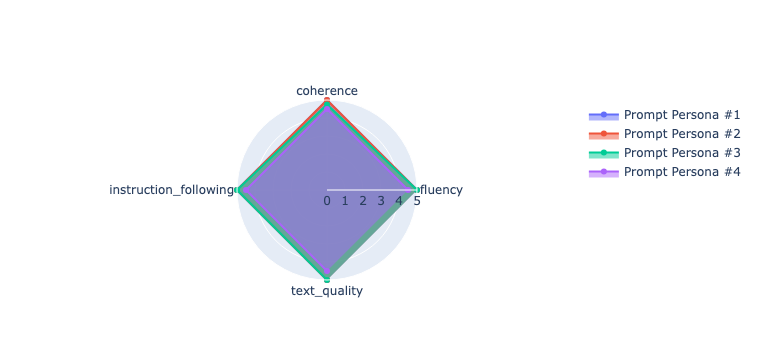

In [ ]:
notebook_utils.display_radar_plot(
    eval_results,
    metrics=["instruction_following", "fluency", "coherence", "text_quality"],
)

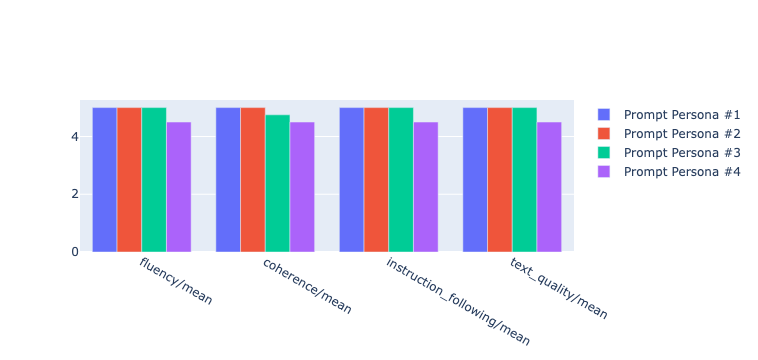

In [ ]:
notebook_utils.display_bar_plot(
    eval_results,
    metrics=["instruction_following", "fluency", "coherence", "text_quality"],
)

In [ ]:
summarization_eval_task.display_runs()

,experiment_name,run_name,run_type,state,param.top_k,param.model_name,param.prompt_template,param.max_output_tokens,param.temperature,metric.instruction_following/std,...,metric.groundedness/std,metric.verbosity/mean,metric.summarization_quality/mean,metric.groundedness/mean,metric.coherence/std,metric.bleu/mean,metric.text_quality/std,metric.safety/mean,metric.text_quality/mean,metric.summarization_quality/std
0,eval-sdk-prompt-engineering,bb05a2a0-0816-47c0-872e-8ced6fa3ee35,system.ExperimentRun,COMPLETE,1.0,publishers/google/models/gemini-2.0-flash,"Instruction: Provide a detailed, factual summa...",256.0,0.3,1.0,...,0.5,-0.25,4.25,0.75,1.0,0.008449,1.0,1.0,4.5,0.957427
1,eval-sdk-prompt-engineering,02e96320-a5b9-48cd-a95d-43ee8668d444,system.ExperimentRun,COMPLETE,1.0,publishers/google/models/gemini-2.0-flash,Instruction: {instruction} such that you're ex...,256.0,0.3,0.0,...,0.5,-0.25,5.00,0.75,0.5,0.009646,0.0,1.0,5.0,0.000000
2,eval-sdk-prompt-engineering,63cb1be5-1c2e-460d-a4ba-02c7deb40db1,system.ExperimentRun,COMPLETE,1.0,publishers/google/models/gemini-2.0-flash,Instruction: {instruction} into three key bull...,256.0,0.3,0.0,...,0.0,0.00,5.00,1.00,0.0,0.010076,0.0,1.0,5.0,0.000000
3,eval-sdk-prompt-engineering,43dba4c5-543a-40c5-8fe5-a6f2764b426f,system.ExperimentRun,COMPLETE,1.0,publishers/google/models/gemini-2.0-flash,Article: {context}. Task: {instruction}. Summary:,256.0,0.3,0.0,...,0.0,0.00,4.50,1.00,0.0,0.012219,0.0,1.0,5.0,1.000000


In [ ]:
delete_experiment = True

# Please set your LOCATION to the same one used during Vertex AI SDK initialization.
LOCATION = "us-central1"  # or whatever region you actually used
# @param {type:"string"}

if delete_experiment:
    from google.cloud import aiplatform
    aiplatform.init(project=PROJECT_ID, location=LOCATION)
    experiment = aiplatform.Experiment(EXPERIMENT_NAME)
    experiment.delete()


Experiment run bb05a2a0-0816-47c0-872e-8ced6fa3ee35 skipped backing tensorboard run deletion.
To delete backing tensorboard run, execute the following:
tensorboard_run_artifact = aiplatform.metadata.artifact.Artifact(artifact_name=f"eval-sdk-prompt-engineering-bb05a2a0-0816-47c0-872e-8ced6fa3ee35-tb-run")
tensorboard_run_resource = aiplatform.TensorboardRun(tensorboard_run_artifact.metadata["resourceName"])
tensorboard_run_resource.delete()
tensorboard_run_artifact.delete()
Deleting Context : projects/703428385522/locations/us-central1/metadataStores/default/contexts/eval-sdk-prompt-engineering-bb05a2a0-0816-47c0-872e-8ced6fa3ee35
Context deleted. . Resource name: projects/703428385522/locations/us-central1/metadataStores/default/contexts/eval-sdk-prompt-engineering-bb05a2a0-0816-47c0-872e-8ced6fa3ee35
Deleting Context resource: projects/703428385522/locations/us-central1/metadataStores/default/contexts/eval-sdk-prompt-engineering-bb05a2a0-0816-47c0-872e-8ced6fa3ee35
Delete Context bac

In [ ]:
   # Evaluation strategy for choosing models
   evaluation_strategy = {
      "dataset_size": "100+ examples for statistical significance",
      "metrics": ["task-specific", "general quality", "efficiency"],
      "comparison_type": "pairwise with statistical testing",
      "baseline": "established_model_or_human_benchmark"
   }

In [ ]:
   # Systematic prompt improvement workflow
   prompt_optimization = {
      "hypothesis": "Clear statement of what you're testing",
      "variants": "3-5 different prompt strategies",
      "evaluation": "Same metrics across all variants",
      "analysis": "Statistical significance + qualitative review"
   }

In [ ]:
   # Production evaluation pipeline
   production_eval = {
      "frequency": "Every model update + weekly monitoring",
      "automation": "CI/CD integration with quality gates",
      "metrics": "Speed + quality + cost tracking",
      "alerting": "Performance degradation detection"
   }